In [ ]:
!pip install torch torchvision transformers datasets opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import numpy as np
import torch
import torchvision.transforms as transforms
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.io import read_image
from torchvision.utils import save_image
from sklearn.model_selection import train_test_split
import cv2


In [ ]:
# Custom Dataset Class

import os
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# Custom Dataset Class
class MADS_Dataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_names = [file_name for file_name in os.listdir(image_dir) if file_name.endswith(".png")]

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        # Image
        image_path = os.path.join(self.image_dir, self.image_names[idx])
        image = Image.open(image_path).convert("RGB")  # Assuming color images

        # Mask
        mask_path = os.path.join(self.mask_dir, self.image_names[idx])  # Assuming mask filenames match image filenames
        mask = Image.open(mask_path).convert("L")  # Assuming a single-channel mask

        # Apply the transforms to both image and mask, including the resizing
        if self.transform:
            image = self.transform(image)
            mask = transforms.ToTensor()(mask)  # Convert mask to tensor first

        # Ensure the mask is transformed appropriately
        mask = transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST)(mask)  # Resize after converting to tensor
        mask = mask.long().squeeze(0)  # Convert to long and squeeze for single-channel

        return image, mask

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to SegFormer input size
    transforms.ToTensor(),          # Convert to tensor
])


In [ ]:
!pip install kaggle


In [ ]:
# Create a directory for Kaggle datasets
!mkdir -p ~/.kaggle

# Move the kaggle.json file to the appropriate directory
!mv kaggle.json ~/.kaggle/

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

# Download the MADS dataset
!kaggle datasets download -d tapakah68/segmentation-full-body-mads-dataset

# Unzip the downloaded dataset
!unzip segmentation-full-body-mads-dataset.zip -d /content/mads_dataset_new


mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/tapakah68/segmentation-full-body-mads-dataset
License(s): Attribution-NoDerivatives 4.0 International (CC BY-ND 4.0)
100% 474M/475M [00:23<00:00, 23.5MB/s]
100% 475M/475M [00:23<00:00, 21.5MB/s]
Archive:  segmentation-full-body-mads-dataset.zip
  inflating: /content/mads_dataset_new/df.csv  
  inflating: /content/mads_dataset_new/segmentation_full_body_mads_dataset_1192_img/segmentation_full_body_mads_dataset_1192_img/collages/HipHop_HipHop1_C0_00180.jpg  
  inflating: /content/mads_dataset_new/segmentation_full_body_mads_dataset_1192_img/segmentation_full_body_mads_dataset_1192_img/collages/HipHop_HipHop1_C0_00225.jpg  
  inflating: /content/mads_dataset_new/segmentation_full_body_mads_dataset_1192_img/segmentation_full_body_mads_dataset_1192_img/collages/HipHop_HipHop1_C0_00360.jpg  
  inflating: /content/mad

In [ ]:
#Define Paths for Images and Masks
image_dir = "/content/mads_dataset_new/segmentation_full_body_mads_dataset_1192_img/segmentation_full_body_mads_dataset_1192_img/images"  # Update with your image directory
mask_dir = "/content/mads_dataset_new/segmentation_full_body_mads_dataset_1192_img/segmentation_full_body_mads_dataset_1192_img/masks"

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to SegFormer input size
    transforms.ToTensor(),
])


In [ ]:
#Create Dataset and DataLoaders
dataset = MADS_Dataset(image_dir, mask_dir, transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)

In [ ]:
# Load Pretrained SegFormer Model for Image Segmentation
from transformers import AutoModelForSemanticSegmentation

model_name = "nvidia/segformer-b0-finetuned-ade-512-512"
model = AutoModelForSemanticSegmentation.from_pretrained(model_name, num_labels=2, ignore_mismatched_sizes=True)  # Adjust num_labels based on your classes, ignore mismatched sizes# Adjust num_labels based on your classes

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
#Training Loop
#Training Loop
import torch
from torch.nn.functional import interpolate
import torch.nn as nn
from torch.nn import functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images).logits
        # Resize the model output using interpolate:
        outputs = interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
        # Ensure masks are long tensors and values are within the valid range (0 and 1)
        masks = masks.long().squeeze(1)  # Convert to long and squeeze
        masks = torch.clamp(masks, 0, 1) # Clamp to the range [0, 1]

        loss = criterion(outputs, masks)  # Adjusting for dimensions
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    torch.cuda.empty_cache()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/3], Loss: 0.0248
Epoch [2/3], Loss: 0.0217
Epoch [3/3], Loss: 0.0202


In [ ]:
import numpy as np
from sklearn.metrics import jaccard_score

def calculate_iou(preds, targets, num_classes):
    # Flatten the arrays to compute metrics
    preds = preds.flatten()
    targets = targets.flatten()

    # Calculate IoU for each class
    iou = []
    for cls in range(num_classes):
        intersection = np.sum((preds == cls) & (targets == cls))
        union = np.sum((preds == cls) | (targets == cls))
        iou.append(intersection / union if union > 0 else 0)
    return np.array(iou)

def pixel_accuracy(preds, targets):
    correct = np.sum(preds == targets)
    total = preds.size
    return correct / total


In [ ]:
# Set the model to evaluation mode
model.eval()

# Lists to hold the metric values
all_iou = []
all_accuracy = []

with torch.no_grad():  # Disable gradient calculation
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)

        # Get model predictions
        outputs = model(images).logits

        # Resize the outputs to match the mask shape
        outputs = interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)

        # Get the predicted class
        preds = outputs.argmax(dim=1)  # Get the class with the highest score

        # Convert predictions and masks to numpy for metric calculations
        preds_np = preds.cpu().numpy()
        masks_np = masks.cpu().numpy()

        # Calculate IoU and pixel accuracy
        iou = calculate_iou(preds_np, masks_np, num_classes=2)  # Update num_classes based on setup
        accuracy = pixel_accuracy(preds_np, masks_np)

        all_iou.append(iou)
        all_accuracy.append(accuracy)

# Convert lists to numpy arrays
all_iou = np.array(all_iou)
all_accuracy = np.array(all_accuracy)

# Average metrics
mean_iou = np.mean(all_iou, axis=0)
mean_accuracy = np.mean(all_accuracy)

print(f'Mean IoU per class: {mean_iou}')
print(f'Mean Pixel Accuracy: {mean_accuracy:.4f}')


Mean IoU per class: [0.99048766 0.74889556]
Mean Pixel Accuracy: 0.9908


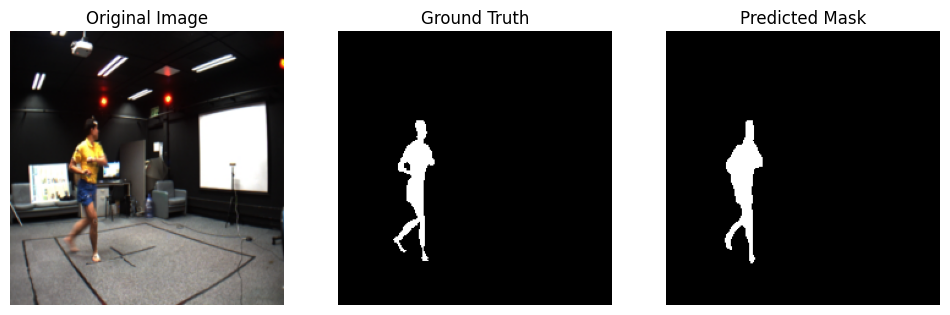

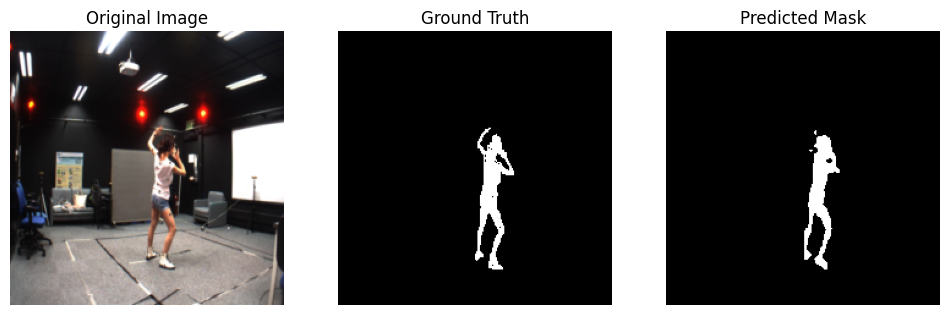

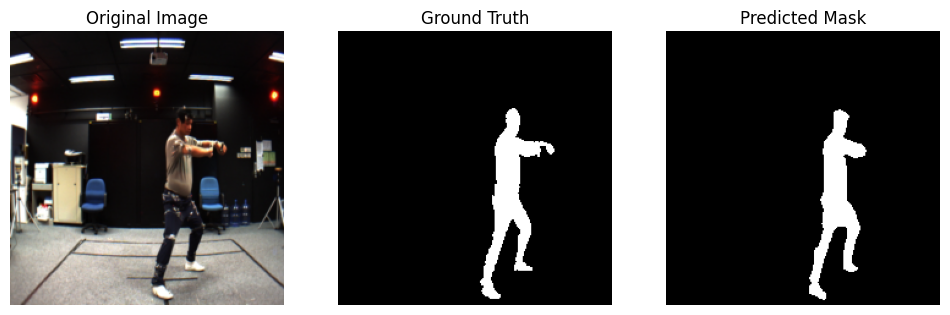

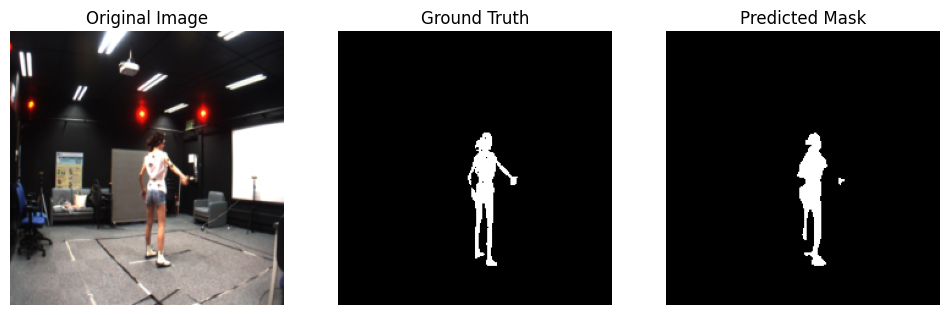

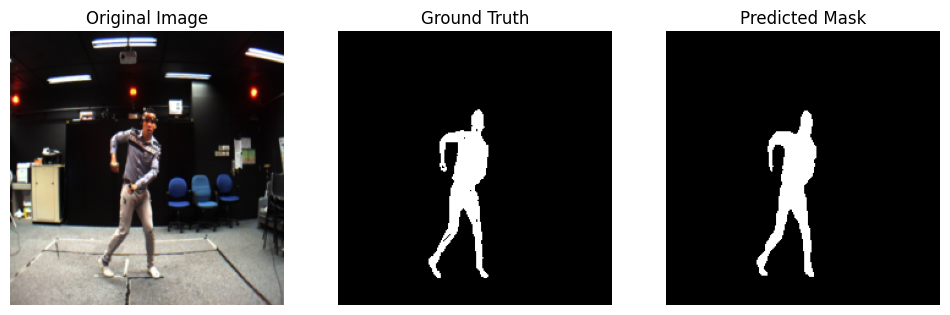

In [ ]:
import matplotlib.pyplot as plt
def visualize_predictions(images, masks, preds, num_images=5):
    # Select a few images to visualize
    for i in range(num_images):
        plt.figure(figsize=(12, 4))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(images[i].cpu().permute(1, 2, 0))
        plt.title("Original Image")
        plt.axis('off')

        # Ground Truth Mask
        plt.subplot(1, 3, 2)
        plt.imshow(masks[i].cpu().squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        # Predicted Mask
        plt.subplot(1, 3, 3)
        plt.imshow(preds[i].cpu().squeeze(), cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')

        plt.show()

# Get a batch of validation data
for images, masks in val_loader:
    images, masks = images.to(device), masks.to(device)
    outputs = model(images).logits
    outputs = interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
    preds = outputs.argmax(dim=1)

    visualize_predictions(images, masks, preds)
    break  # Only visualize the first batch
